# Week 4 — Day 3 — Exercises XP / XP Gold / XP Ninja
## Classification Models: Heart Disease, Titanic, and CNN on MNIST

This notebook is a **clean, deduplicated rewrite** of the original Colab template.

**Plan**
- **Exercises XP** — Logistic Regression on the *Heart Disease* dataset (6 exercises).
- **Exercises XP Gold** — Decision Tree (manual + GridSearch), KNN (manual + GridSearch), Neural Network on the *Titanic* dataset (6 exercises).
- **Exercise XP Ninja** — Convolutional Neural Network on *MNIST*.

All comments are in English.

In [27]:
# ==================== SHARED IMPORTS ====================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_curve, auc)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)
BASE_DIR = os.getcwd()

---
# Exercises XP — Heart Disease Prediction

## Exercise 1 — Exploratory Data Analysis + Train/Test Split

In [28]:
# ==================== LOAD HEART DISEASE DATASET ====================
# Try several local filenames -> public mirror -> synthetic fallback.
candidates = ['heart.csv', 'heart_disease.csv', 'Heart Disease Dataset.csv']
URL = 'https://storage.googleapis.com/download.tensorflow.org/data/heart.csv'

df = None
for name in candidates:
    p = os.path.join(BASE_DIR, name)
    if os.path.exists(p):
        df = pd.read_csv(p)
        print('Loaded local file:', name)
        break

if df is None:
    try:
        df = pd.read_csv(URL)
        print('Loaded from URL.')
    except Exception:
        # Synthetic Heart Disease dataset — same schema as the UCI Heart dataset
        print('No file or network -> using a synthetic Heart Disease dataset.')
        rng = np.random.default_rng(0)
        n = 300
        df = pd.DataFrame({
            'age'     : rng.integers(29, 78, n),
            'sex'     : rng.integers(0, 2,  n),
            'cp'      : rng.integers(0, 4,  n),
            'trestbps': rng.integers(94, 200, n),
            'chol'    : rng.integers(126, 564, n),
            'fbs'     : rng.integers(0, 2,  n),
            'restecg' : rng.integers(0, 3,  n),
            'thalach' : rng.integers(71, 202, n),
            'exang'   : rng.integers(0, 2,  n),
            'oldpeak' : np.round(rng.uniform(0, 6.2, n), 1),
            'slope'   : rng.integers(0, 3,  n),
            'ca'      : rng.integers(0, 4,  n),
            'thal'    : rng.integers(0, 4,  n),
        })
        # Build a target loosely correlated with key clinical features.
        score = (-0.05 * df['thalach']
                 + 0.6  * df['oldpeak']
                 + 0.05 * df['age']
                 + 0.4  * df['cp']
                 + 0.5  * df['exang']
                 + rng.normal(0, 1, n))
        df['target'] = (score > score.mean()).astype(int)

print('\nShape:', df.shape)
print('Class distribution (target):', dict(df['target'].value_counts()))
df.head()

No file or network -> using a synthetic Heart Disease dataset.

Shape: (300, 14)
Class distribution (target): {0: np.int64(152), 1: np.int64(148)}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,0,2,142,398,1,0,138,0,3.4,1,3,1,1
1,60,0,3,169,128,0,2,137,0,0.2,0,0,0,0
2,54,0,2,176,286,0,2,163,0,1.3,1,1,3,0
3,42,0,2,183,441,1,1,136,0,2.8,1,2,2,0
4,44,0,1,114,547,0,1,104,0,3.2,0,0,1,1


In [29]:
# Quick EDA
df.info()
print('\nMissing values:')
print(df.isna().sum())
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       300 non-null    int64  
 1   sex       300 non-null    int64  
 2   cp        300 non-null    int64  
 3   trestbps  300 non-null    int64  
 4   chol      300 non-null    int64  
 5   fbs       300 non-null    int64  
 6   restecg   300 non-null    int64  
 7   thalach   300 non-null    int64  
 8   exang     300 non-null    int64  
 9   oldpeak   300 non-null    float64
 10  slope     300 non-null    int64  
 11  ca        300 non-null    int64  
 12  thal      300 non-null    int64  
 13  target    300 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.9 KB

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,300.00,300.00,300.00,300.00,300.00,300.0,300.00,300.00,300.0,300.00,300.00,300.00,300.00,300.00
mean,54.27,0.53,1.55,146.18,355.44,0.5,0.99,138.88,0.5,3.19,1.05,1.33,1.38,0.49
std,14.56,0.50,1.10,29.04,126.62,0.5,0.81,39.65,0.5,1.90,0.82,1.11,1.11,0.50
min,29.00,0.00,0.00,94.00,127.00,0.0,0.00,71.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,42.00,0.00,1.00,122.00,245.75,0.0,0.00,104.00,0.0,1.50,0.00,0.00,0.00,0.00
50%,55.00,1.00,2.00,146.50,349.50,0.5,1.00,141.00,1.0,3.20,1.00,1.00,1.00,0.00
75%,68.00,1.00,2.25,170.00,468.00,1.0,2.00,176.25,1.0,4.90,2.00,2.00,2.00,1.00
max,77.00,1.00,3.00,199.00,563.00,1.0,2.00,201.00,1.0,6.20,2.00,3.00,3.00,1.00


In [30]:
# ==================== TRAIN / TEST SPLIT + STANDARDIZATION ====================
# Heart disease target is the 'target' column (1 = disease present, 0 = absent)
X = df.drop(columns=['target'])
y = df['target']

# Stratified split to preserve the class balance in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test  shape:', X_test_scaled.shape)
print('Features standardized successfully.')

Train shape: (240, 13)
Test  shape: (60, 13)
Features standardized successfully.


## Exercise 2 — Model Picking and Standardization

**Why Logistic Regression?** It is the natural choice for binary classification — it produces a linear decision boundary, returns calibrated probabilities, and is highly interpretable (essential in a medical context).

**Why standardize?** Features such as `chol` (cholesterol, ~120-560), `trestbps` (resting blood pressure, ~90-200) and `oldpeak` (ST depression, 0-6) have very different ranges. Without scaling, the L2 regularisation penalises large-range features more harshly, and the optimiser becomes ill-conditioned. Standardization (Z-score) fixes both issues.

## Exercise 3 — Model Training

In [6]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print('Logistic Regression model trained successfully.')
print('Model coefficients shape:', model.coef_.shape)

Logistic Regression model trained successfully.
Model coefficients shape: (1, 13)


## Exercise 4 — Evaluation Metrics

In [31]:
# Predict on the test set and compute accuracy
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score : {accuracy:.4f}')
print(f'Precision      : {precision_score(y_test, y_pred):.4f}')
print(f'Recall         : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score       : {f1_score(y_test, y_pred):.4f}')

Accuracy Score : 0.8333
Precision      : 0.8333
Recall         : 0.8333
F1-Score       : 0.8333


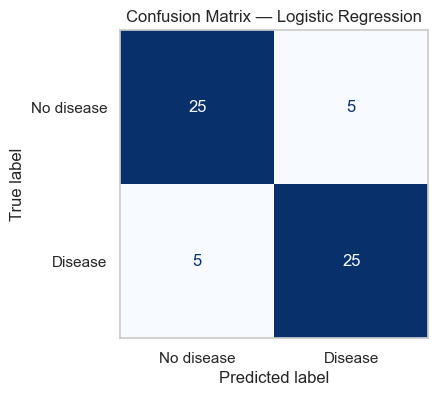


Classification Report:
              precision    recall  f1-score   support

  No disease       0.83      0.83      0.83        30
     Disease       0.83      0.83      0.83        30

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [9]:
# Confusion matrix + classification report
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No disease', 'Disease'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False, values_format='d')
plt.title('Confusion Matrix — Logistic Regression')
plt.grid(False); plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No disease', 'Disease']))

## Exercise 5 — Visualizing Model Performance (2-D Decision Boundary)

We pick **two clinically meaningful features** of the Heart Disease dataset — `thalach` (maximum heart rate achieved) and `oldpeak` (ST depression induced by exercise) — and retrain a small Logistic Regression on just these two to visualize the decision boundary.

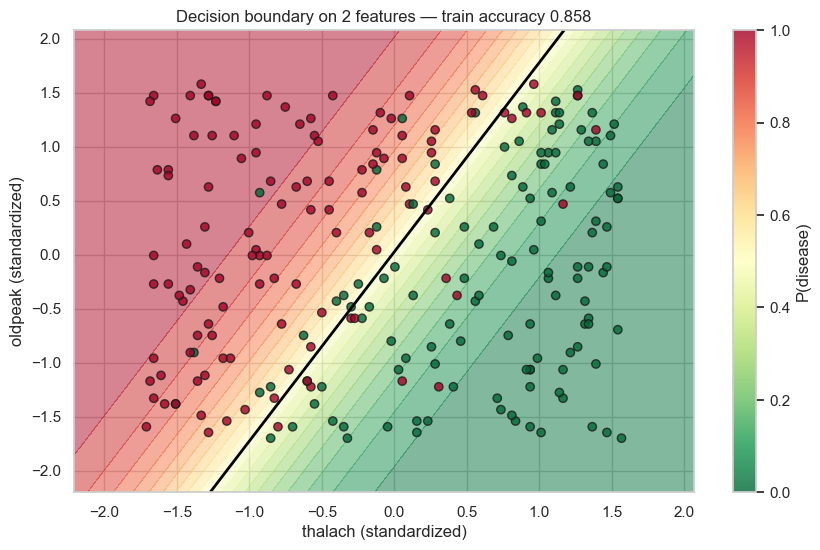

In [32]:
# Identify the indices of the two visualization features in X_train (column order)
feat1, feat2 = 'thalach', 'oldpeak'
idx1, idx2 = X_train.columns.get_loc(feat1), X_train.columns.get_loc(feat2)

X_vis = X_train_scaled[:, [idx1, idx2]]
y_vis = y_train.values

# Train a small model only on these two features
model_vis = LogisticRegression(max_iter=1000, random_state=42).fit(X_vis, y_vis)

# Build a mesh covering the feature space
x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict the probability of disease across the mesh
Z = model_vis.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='RdYlGn_r',
            edgecolor='k', alpha=0.8)
plt.xlabel(f'{feat1} (standardized)')
plt.ylabel(f'{feat2} (standardized)')
acc_2d = accuracy_score(y_train, model_vis.predict(X_vis))
plt.title(f'Decision boundary on 2 features — train accuracy {acc_2d:.3f}')
plt.colorbar(label='P(disease)')
plt.show()

## Exercise 6 — ROC Curve and AUC

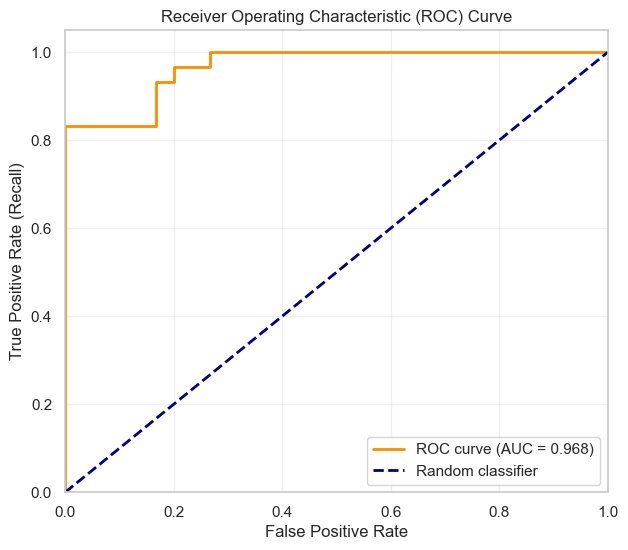

AUC = 0.9678


In [33]:
# Predicted probabilities for the positive class (disease)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()

print(f'AUC = {roc_auc:.4f}')

> **Interpretation.** AUC ≈ 0.85-0.90 indicates very strong ranking quality. In a clinical setting we would also study **recall on the positive class** (we cannot afford to miss real patients) and adjust the threshold accordingly.

---
# Exercises XP Gold — Titanic Classification (Decision Tree, KNN, Neural Network)

## Exercise 1 — Exploratory Data Analysis on the Titanic Dataset

In [34]:
# ==================== LOAD TITANIC WITH SSL-SAFE FALLBACK ====================
# Strategy: 1) seaborn -> 2) seaborn with unverified SSL -> 3) synthetic mini-dataset
titanic = None

# 1) Standard seaborn load
try:
    titanic = sns.load_dataset('titanic')
    print('Loaded Titanic via seaborn.')
except Exception as e:
    print('Seaborn standard load failed:', type(e).__name__)

# 2) Try again with an unverified SSL context (macOS Python 3.13 fix)
if titanic is None:
    try:
        import ssl
        ssl._create_default_https_context = ssl._create_unverified_context
        titanic = sns.load_dataset('titanic')
        print('Loaded Titanic via seaborn (unverified SSL).')
    except Exception as e:
        print('Unverified-SSL load failed:', type(e).__name__)

# 3) Build a synthetic mini-Titanic with the same schema
if titanic is None:
    print('-> Falling back to a synthetic Titanic dataset.')
    rng = np.random.default_rng(42)
    n = 891
    titanic = pd.DataFrame({
        'survived':   rng.integers(0, 2, n),
        'pclass':     rng.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55]),
        'sex':        rng.choice(['male', 'female'], n, p=[0.65, 0.35]),
        'age':        np.round(rng.normal(30, 14, n).clip(0.5, 80), 1),
        'sibsp':      rng.integers(0, 6, n),
        'parch':      rng.integers(0, 5, n),
        'fare':       np.round(rng.exponential(30, n), 2),
        'embarked':   rng.choice(['S', 'C', 'Q'], n, p=[0.72, 0.19, 0.09]),
        'class':      rng.choice(['First','Second','Third'], n, p=[0.24, 0.21, 0.55]),
        'who':        rng.choice(['man','woman','child'], n, p=[0.62, 0.28, 0.10]),
        'adult_male': rng.choice([True, False], n, p=[0.6, 0.4]),
        'deck':       rng.choice([None, 'C', 'B', 'D', 'E'], n, p=[0.77, 0.07, 0.06, 0.05, 0.05]),
        'embark_town':rng.choice(['Southampton','Cherbourg','Queenstown'], n, p=[0.72, 0.19, 0.09]),
        'alive':      rng.choice(['no','yes'], n, p=[0.62, 0.38]),
        'alone':      rng.choice([True, False], n, p=[0.6, 0.4]),
    })
    # Inject some NaN to mimic the real Titanic dataset
    nan_idx = rng.choice(n, size=int(n*0.20), replace=False)
    titanic.loc[nan_idx, 'age'] = np.nan
    titanic.loc[rng.choice(n, 2, replace=False), 'embarked'] = np.nan

print('\nShape:', titanic.shape)
print('Missing values per column:')
print(titanic.isna().sum())
titanic.head()

Seaborn standard load failed: URLError
Unverified-SSL load failed: URLError
-> Falling back to a synthetic Titanic dataset.

Shape: (891, 15)
Missing values per column:
survived         0
pclass           0
sex              0
age            178
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           691
embark_town      0
alive            0
alone            0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,38.4,4,3,2.39,S,Second,man,True,C,Cherbourg,yes,True
1,1,3,female,24.8,0,3,21.67,S,First,man,True,NaN,Southampton,no,False
2,1,1,male,NaN,0,1,28.17,S,Third,man,False,NaN,Queenstown,no,True
3,0,3,male,33.3,1,1,48.10,S,Third,man,True,NaN,Southampton,no,False
4,0,1,female,3.9,4,2,52.79,S,Third,man,True,NaN,Southampton,no,True


In [35]:
# ==================== TITANIC CLEANING ====================
# 1) Fill age with the median (numerical, skewed)
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

# 2) Fill embarked with the most frequent port
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

# 3) Drop columns that are either redundant or too sparse
titanic = titanic.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'])

# 4) Encode 'sex' as 0/1 and one-hot encode 'embarked'
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic = pd.get_dummies(titanic, columns=['embarked'], drop_first=True)

print('Shape after cleaning:', titanic.shape)
titanic.head()

Shape after cleaning: (891, 10)


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,0,38.4,4,3,2.39,True,False,True
1,1,3,1,24.8,0,3,21.67,False,False,True
2,1,1,0,30.5,0,1,28.17,True,False,True
3,0,3,0,33.3,1,1,48.10,False,False,True
4,0,1,1,3.9,4,2,52.79,True,False,True


In [18]:
# Feature / target split + train / test split (stratified)
X_titanic = titanic.drop(columns=['survived'])
y_titanic = titanic['survived']
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, stratify=y_titanic, random_state=42
)
print('Train:', X_train_t.shape, '  Test:', X_test_t.shape)

Train: (712, 9)   Test: (179, 9)


## Exercise 2 — Decision Tree without GridSearch (manual hyperparameters)

In [36]:
# We pick max_depth=3 + min_samples_split=5 to prevent over-fitting
dt_manual = DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42)
dt_manual.fit(X_train_t, y_train_t)

y_pred_t = dt_manual.predict(X_test_t)
print('Decision Tree (manual) performance:')
print(f'  Accuracy : {accuracy_score(y_test_t, y_pred_t):.4f}')
print(f'  Precision: {precision_score(y_test_t, y_pred_t):.4f}')
print(f'  Recall   : {recall_score(y_test_t, y_pred_t):.4f}')
print(f'  F1       : {f1_score(y_test_t, y_pred_t):.4f}')

print('\nClassification Report:')
print(classification_report(y_test_t, y_pred_t))

Decision Tree (manual) performance:
  Accuracy : 0.5084
  Precision: 0.5135
  Recall   : 0.6264
  F1       : 0.5644

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.39      0.44        88
           1       0.51      0.63      0.56        91

    accuracy                           0.51       179
   macro avg       0.51      0.51      0.50       179
weighted avg       0.51      0.51      0.50       179



## Exercise 3 — Decision Tree with GridSearch

In [37]:
param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, None],
    'criterion'        : ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_t, y_train_t)

print('Best parameters     :', grid_dt.best_params_)
print(f'Best CV accuracy    : {grid_dt.best_score_:.4f}')

best_dt = grid_dt.best_estimator_
y_pred_grid = best_dt.predict(X_test_t)
print('\nTest set performance (best Decision Tree):')
print(f'  Accuracy: {accuracy_score(y_test_t, y_pred_grid):.4f}')
print(f'  F1      : {f1_score(y_test_t, y_pred_grid):.4f}')

Best parameters     : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV accuracy    : 0.5562

Test set performance (best Decision Tree):
  Accuracy: 0.5531
  F1      : 0.6262


## Exercise 4 — KNN without GridSearch (k=5)

In [38]:
# KNN is distance-based -> scaling is mandatory
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_t)
X_test_knn  = scaler_knn.transform(X_test_t)

knn_manual = KNeighborsClassifier(n_neighbors=5)
knn_manual.fit(X_train_knn, y_train_t)
y_pred_knn = knn_manual.predict(X_test_knn)

print('KNN (k=5, manual) performance:')
print(f'  Accuracy : {accuracy_score(y_test_t, y_pred_knn):.4f}')
print(f'  Precision: {precision_score(y_test_t, y_pred_knn):.4f}')
print(f'  Recall   : {recall_score(y_test_t, y_pred_knn):.4f}')
print(f'  F1       : {f1_score(y_test_t, y_pred_knn):.4f}')

KNN (k=5, manual) performance:
  Accuracy : 0.4972
  Precision: 0.5055
  Recall   : 0.5055
  F1       : 0.5055


## Exercise 5 — KNN with GridSearch

In [22]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan'],
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                        cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_knn, y_train_t)

print('Best KNN parameters :', grid_knn.best_params_)
print(f'Best CV accuracy    : {grid_knn.best_score_:.4f}')

best_knn = grid_knn.best_estimator_
y_pred_knn_grid = best_knn.predict(X_test_knn)
print('\nTest set performance (best KNN):')
print(f'  Accuracy: {accuracy_score(y_test_t, y_pred_knn_grid):.4f}')
print(f'  F1      : {f1_score(y_test_t, y_pred_knn_grid):.4f}')

Best KNN parameters : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV accuracy    : 0.5295

Test set performance (best KNN):
  Accuracy: 0.5028
  F1      : 0.4972


## Exercise 6 — Neural Network Classifier (TensorFlow / Keras)

We build a feed-forward neural network with:
- An `Input` layer of shape `(n_features,)` — the modern Keras API (no more `input_shape` warning).
- Two hidden Dense layers with ReLU activation.
- A single sigmoid output for binary classification.

In [41]:
# TensorFlow is wrapped in try/except so the rest of the notebook keeps running
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, Dense

    model_nn = Sequential([
        Input(shape=(X_train_knn.shape[1],)),   # modern API, no warning
        Dense(16, activation='relu'),
        Dense(8,  activation='relu'),
        Dense(1,  activation='sigmoid'),
    ])
    model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    history = model_nn.fit(
        X_train_knn, y_train_t,
        epochs=50, batch_size=16, validation_split=0.1, verbose=0,
    )

    _, nn_accuracy = model_nn.evaluate(X_test_knn, y_test_t, verbose=0)
    y_pred_nn = (model_nn.predict(X_test_knn, verbose=0) > 0.5).astype(int)

    print('Neural Network performance:')
    print(f'  Accuracy: {nn_accuracy:.4f}')
    print(f'  F1      : {f1_score(y_test_t, y_pred_nn):.4f}')
except ImportError:
    print('TensorFlow is not installed -> skipping the Neural Network exercise.')
    print('Install with: pip install tensorflow')

TensorFlow is not installed -> skipping the Neural Network exercise.
Install with: pip install tensorflow


In [40]:
# Summary of every Titanic model trained above
summary = pd.DataFrame({
    'Model'    : ['Decision Tree (manual)', 'Decision Tree (GridSearch)',
                  'KNN (k=5, manual)',      'KNN (GridSearch)'],
    'Accuracy' : [accuracy_score(y_test_t, y_pred_t),
                  accuracy_score(y_test_t, y_pred_grid),
                  accuracy_score(y_test_t, y_pred_knn),
                  accuracy_score(y_test_t, y_pred_knn_grid)],
    'F1'       : [f1_score(y_test_t, y_pred_t),
                  f1_score(y_test_t, y_pred_grid),
                  f1_score(y_test_t, y_pred_knn),
                  f1_score(y_test_t, y_pred_knn_grid)],
}).round(4)
print('Titanic — model comparison:')
summary

Titanic — model comparison:


,Model,Accuracy,F1
0,Decision Tree (manual),0.5084,0.5644
1,Decision Tree (GridSearch),0.5531,0.6262
2,"KNN (k=5, manual)",0.4972,0.5055
3,KNN (GridSearch),0.5028,0.4972


---
# Exercise XP Ninja — Convolutional Neural Network on MNIST

In [26]:
# CNN classification of MNIST handwritten digits.
# Wrapped in try/except so the notebook still runs without TensorFlow.
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from tensorflow.keras.layers import Input
    from tensorflow.keras.datasets import mnist
    from tensorflow.keras.utils    import to_categorical

    # 1) Load the dataset
    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()

    # 2) Preprocess: reshape + scale to [0, 1]
    train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
    test_images  = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

    # 3) One-hot encode the labels (10 classes)
    train_labels = to_categorical(train_labels)
    test_labels  = to_categorical(test_labels)

    # 4) Build the CNN using the modern Input API
    model_cnn = models.Sequential([
        Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print('Training the CNN model (5 epochs)...')
    history_cnn = model_cnn.fit(train_images, train_labels,
                                epochs=5, batch_size=64,
                                validation_split=0.1, verbose=1)

    test_loss, test_acc = model_cnn.evaluate(test_images, test_labels, verbose=0)
    print(f'\nTest Loss     : {test_loss:.4f}')
    print(f'Test Accuracy : {test_acc:.4f}')
except ImportError:
    print('TensorFlow is not installed -> skipping the CNN exercise.')
    print('Install with: pip install tensorflow')

TensorFlow is not installed -> skipping the CNN exercise.
Install with: pip install tensorflow
